In [102]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras import layers
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
from statistics import mean
from statistics import stdev
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Concatenate, Activation, Conv2D, MaxPooling2D, Flatten, Input
import cv2
%matplotlib inline
#The line above is necesary to show Matplotlib's plots inside a Jupyter Notebook

from matplotlib import pyplot as plt

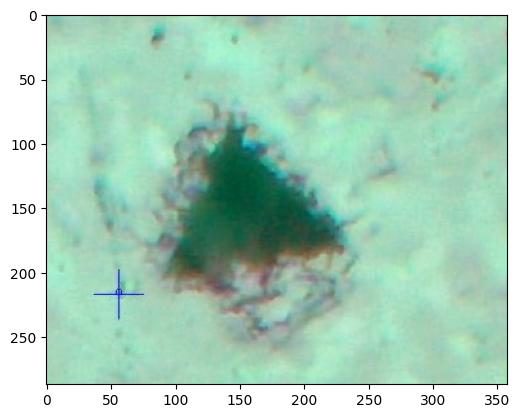

In [103]:
IMG_SIZE=224

resize = tf.keras.Sequential([  layers.Resizing(IMG_SIZE, IMG_SIZE)])
image_path = '/Users/greysonnewton/Library/CloudStorage/OneDrive-UniversityOfHouston/FALL_2025/Big Data Analytics (PETR)/big-data-analytics/big-data-analytics/lectures/L10/3438.JPG'
journal_image0 = cv2.imread(image_path)
#Show the image with matplotlib
plt.imshow(journal_image0)
plt.show()

In [121]:
import cv2
import numpy as np
import random

class ImageAugmentor:
    def __init__(self, image):
        """
        Initialize with a loaded image (numpy array).
        """
        self.image = image.copy()

    def resize(self, width, height):
        self.image = cv2.resize(self.image, (width, height))
        return self

    def rotate(self, angle, center=None, scale=1.0):
        (h, w) = self.image.shape[:2]
        if center is None:
            center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, scale)
        self.image = cv2.warpAffine(self.image, M, (w, h))
        return self

    def crop(self, x=0, y=0, width=None, height=None, crop_factor:float=0.5,mode='manual'):
        """
        Crop the image.

        Args:
            x, y: Top-left corner (only used in 'manual' mode).
            width, height: Size of the crop (optional in 'center' and 'corner' modes).
            mode: 'manual', 'center', or 'top_left'
        """
        h, w = self.image.shape[:2]

        if mode == 'manual':
            if width is None or height is None:
                raise ValueError("Must provide width and height for manual crop")
            self.image = self.image[y:y+height, x:x+width]

        elif mode == 'center':

            h, w = self.image.shape[:2]
            new_w = int(w * crop_factor)
            new_h = int(h * crop_factor)
            left = (w - new_w) // 2
            top = (h - new_h) // 2
            self.image = self.image[top:top + new_h, left:left + new_w]

        elif mode == 'top_left':
            crop_w = width or w // 2
            crop_h = height or h // 2
            self.image = self.image[0:crop_h, 0:crop_w]

        else:
            raise ValueError("Invalid crop mode. Use 'manual', 'center', or 'top_left'.")

        return self

    def flip(self, direction='horizontal'):
        if direction == 'horizontal':
            self.image = cv2.flip(self.image, 1)
        elif direction == 'vertical':
            self.image = cv2.flip(self.image, 0)
        elif direction == 'both':
            self.image = cv2.flip(self.image, -1)
        return self

    def adjust_brightness_contrast(self, brightness=0, contrast=0):
        # brightness [-100, 100], contrast [-100, 100]
        beta = brightness
        alpha = 1 + (contrast / 100.0)
        self.image = cv2.convertScaleAbs(self.image, alpha=alpha, beta=beta)
        return self

    def blur(self, kernel_size=5):
        self.image = cv2.GaussianBlur(self.image, (kernel_size, kernel_size), 0)
        return self

    def sharpen(self):
        kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
        self.image = cv2.filter2D(self.image, -1, kernel)
        return self

    def add_noise(self, amount=0.05):
        # gaussian distribution
        noise = np.random.randn(*self.image.shape) * 255 * amount
        noisy_image = self.image.astype(np.float32) + noise
        self.image = np.clip(noisy_image, 0, 255).astype(np.uint8)
        return self

    def color_jitter(self, h_shift=10, s_shift=30, v_shift=30):
        hsv = cv2.cvtColor(self.image, cv2.COLOR_BGR2HSV).astype(np.int32)
        hsv[..., 0] = (hsv[..., 0] + random.randint(-h_shift, h_shift)) % 180
        hsv[..., 1] = np.clip(hsv[..., 1] + random.randint(-s_shift, s_shift), 0, 255)
        hsv[..., 2] = np.clip(hsv[..., 2] + random.randint(-v_shift, v_shift), 0, 255)
        self.image = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
        return self

    def affine_transform(self, matrix):
        rows, cols = self.image.shape[:2]
        self.image = cv2.warpAffine(self.image, matrix, (cols, rows))
        return self

    def normalize(self, mean, std):
        self.image = (self.image.astype(np.float32) - mean) / std
        return self

    def get_image(self):
        return self.image

    def reset(self, original):
        self.image = original.copy()
        return self

    def show(self):
        plt.imshow(self.image)


    def random_translation(self, max_tx=0.2, max_ty=0.2):
        """
        Apply a random translation to the image.

        Args:
            max_tx: Max translation as a fraction of image width (e.g., 0.2 = 20%)
            max_ty: Max translation as a fraction of image height
        """
        h, w = self.image.shape[:2]
        tx = int(random.uniform(-max_tx, max_tx) * w)
        ty = int(random.uniform(-max_ty, max_ty) * h)

        M = np.float32([[1, 0, tx],
                        [0, 1, ty]])

        self.image = cv2.warpAffine(self.image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        return self

    def random_brightness(self, max_delta=50):
        """
        Apply random brightness adjustment.

        Args:
            max_delta: Maximum change in brightness (range: [-max_delta, +max_delta])
        """
        delta = random.randint(-max_delta, max_delta)
        self.image = cv2.convertScaleAbs(self.image, alpha=1, beta=delta)
        return self

    def resize_to(self, size):
        """
        Resize the image to a given (width, height) tuple.

        Args:
            size: Tuple of (width, height)
        """
        self.image = cv2.resize(self.image, size)
        return self
    # def random_translation(self):
    #     return layers.RandomTranslation(0.5,0.5,fill_mode='reflect',interpolation='bilinear')


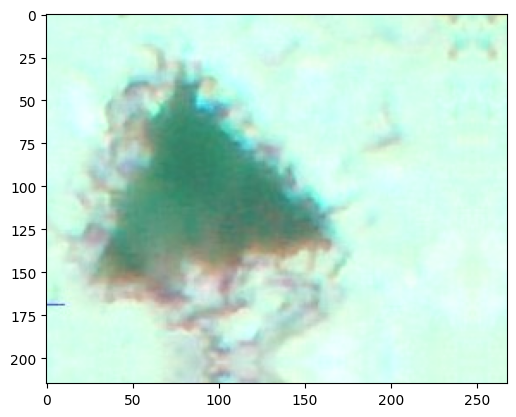

In [132]:
image_path = '/Users/greysonnewton/Library/CloudStorage/OneDrive-UniversityOfHouston/FALL_2025/Big Data Analytics (PETR)/big-data-analytics/big-data-analytics/lectures/L10/3438.JPG'
journal_image0 = cv2.imread(image_path)

augmentor = ImageAugmentor(journal_image0)
# augmentor.sharpen()
augmentor.crop(mode='center',crop_factor=0.75)
augmentor.random_translation()
augmentor.random_brightness(max_delta=75)
# augmentor.add_noise(amount=0.3)
plt.imshow(augmentor.image)


In [ ]:
def calculate_data_loss_ratio(input_size, kernel_size, stride):
    """
    Calculate the ratio and percentage of data loss due to pooling.

    Args:
        input_size (int or tuple): Size of input (e.g., 32 or (32, 32))
        kernel_size (int or tuple): Pooling kernel size
        stride (int or tuple): Pooling stride

    Returns:
        tuple: (loss_ratio, loss_percentage)
    """
    from math import floor

    if isinstance(input_size, int):
        input_size = (input_size,)
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size,) * len(input_size)
    if isinstance(stride, int):
        stride = (stride,) * len(input_size)

    total_elements = 1
    retained_elements = 1

    for i_size, k_size, s in zip(input_size, kernel_size, stride):
        total_elements *= i_size
        steps = floor((i_size - k_size) / s) + 1
        output_size = steps
        retained_elements *= output_size

    loss_elements = total_elements - retained_elements
    loss_ratio = loss_elements / total_elements
    loss_percentage = 100 * loss_ratio

    return loss_ratio, loss_percentage

ratio, percent = calculate_data_loss_ratio((243, 243), kernel_size=3, stride=2)
print(f"Data loss ratio: {ratio:.4f}")
print(f"Data loss percentage: {percent:.2f}%")